In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertModel, BertTokenizer
from sklearn.mixture import GaussianMixture

### TTCT dataset

In [2]:
kodetu_creat_test = pd.read_csv('TTCT_AUT_LOG.csv')

In [3]:
kodetu_creat_test.columns

Index(['User', 'Age', 'Gender', 'Class', 'CodeKnow', 'TechAff',
       'TechAff_median', 'Pre_Post', 'Pre_Post_INT', 'TTCTPre', 'TTCTPost',
       'KODETU_Pre', 'KODETU_Post', 'INT_sessions', 'INT_sessions_not_zero',
       'INT_sessions_true_false', 'INT_count_items', 'TTCT_PRE_fluency',
       'TTCT_PRE_fluency_log', 'TTCT_PRE_originality',
       'TTCT_PRE_originality_log', 'TTCT_PRE_flexibility',
       'TTCT_PRE_elaboration', 'TTCT_PRE_creativityIndex', 'TTCT_POST_fluency',
       'TTCT_POST_fluency_log', 'TTCT_POST_originality',
       'TTCT_POST_originality_log', 'TTCT_POST_flexibility',
       'TTCT_POST_elaboration', 'TTCT_POST_creativityIndex', 'KODETU_PRE_maxL',
       'KODETU_PRE_maxL_success', 'KODETU_PRE_avg_totalAttmp',
       'KODETU_PRE_Avg_SuccessAttempts', 'KODETU_PRE_TotalTime',
       'KODETU_PRE_AvgTime', 'KODETU_PRE_AvgOrig', 'KODETU_POST_maxL',
       'KODETU_POST_maxL_success', 'KODETU_POST_avg_totalAttmp',
       'KODETU_POST_Avg_SuccessAttempts', 'KODETU_POST

In [4]:
filtered_columns = kodetu_creat_test[['TTCT_PRE_fluency','TTCT_PRE_elaboration','TTCT_PRE_flexibility','TTCT_PRE_originality']]

In [5]:
kodetu_creat_test[(filtered_columns != '.').all(axis=1)]

,User,Age,Gender,Class,CodeKnow,TechAff,TechAff_median,Pre_Post,Pre_Post_INT,TTCTPre,...,KODETU_PRE_TotalTime,KODETU_PRE_AvgTime,KODETU_PRE_AvgOrig,KODETU_POST_maxL,KODETU_POST_maxL_success,KODETU_POST_avg_totalAttmp,KODETU_POST_Avg_SuccessAttempts,KODETU_POST_TotalTime,KODETU_POST_AvgTime,KODETU_POST_AvgOrig
9,d2o740,14,1,2a,0,10,2,0,0,1,...,14.21666667,1.777083334,0.452467925,.,.,.,.,.,.,.
10,ejvxz3,14,1,8a,0,6,2,0,0,1,...,6.51666666,0.814583333,0.37662377,.,.,.,.,.,.,.
11,dn31ml,.,.,.,.,.,.,0,0,1,...,.,.,.,.,.,.,.,.,.,.
12,evvk8l,14,2,9a,0,8,2,0,0,1,...,24.9,3.112499999,0.433371371,.,.,.,.,.,.,.
13,em20wx,15,2,7a,0,10,2,0,0,1,...,11.43333333,1.429166667,0.518729972,.,.,.,.,.,.,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,dw1l3o,14,2,1b,0,5,1,1,1,1,...,16.6,2.075,0.551806037,10,10,5.9,1,18.16666667,1.816666667,0.693903566
229,e7jnp8,14,1,3a,0,8,2,1,1,1,...,12.83333331,1.604166663,0.581415668,10,10,2,1,9.783333326,0.978333333,0.62763107
232,d52lmv,14,1,9b,1,7,2,1,0,1,...,12.35000002,1.543750002,0.483780659,10,10,4.4,1.1,17.11666667,1.711666667,0.616409062
233,dqx4r5,14,2,2b,0,10,2,1,0,1,...,36.09999999,4.512499999,0.556878706,10,10,2.9,1.3,19.36666667,1.936666667,0.65527831


In [6]:
df = kodetu_creat_test[(filtered_columns != '.').all(axis=1)]

In [7]:
df.head()

,User,Age,Gender,Class,CodeKnow,TechAff,TechAff_median,Pre_Post,Pre_Post_INT,TTCTPre,...,KODETU_PRE_TotalTime,KODETU_PRE_AvgTime,KODETU_PRE_AvgOrig,KODETU_POST_maxL,KODETU_POST_maxL_success,KODETU_POST_avg_totalAttmp,KODETU_POST_Avg_SuccessAttempts,KODETU_POST_TotalTime,KODETU_POST_AvgTime,KODETU_POST_AvgOrig
9,d2o740,14,1,2a,0,10,2,0,0,1,...,14.21666667,1.777083334,0.452467925,.,.,.,.,.,.,.
10,ejvxz3,14,1,8a,0,6,2,0,0,1,...,6.51666666,0.814583333,0.37662377,.,.,.,.,.,.,.
11,dn31ml,.,.,.,.,.,.,0,0,1,...,.,.,.,.,.,.,.,.,.,.
12,evvk8l,14,2,9a,0,8,2,0,0,1,...,24.9,3.112499999,0.433371371,.,.,.,.,.,.,.
13,em20wx,15,2,7a,0,10,2,0,0,1,...,11.43333333,1.429166667,0.518729972,.,.,.,.,.,.,.


In [8]:
df["Age"].unique()

array(['14', '.', '15'], dtype=object)

### Kodetu interactions dataset

In [9]:
kodetu_data = pd.read_csv('kodetuTau-interactions_pre_post.csv')

In [10]:
# Select all rows where the 'XMLPseudocode' column contains the word "EXECUTE"
mask = kodetu_data["XMLPseudocode()"].str.contains('EXECUTE')
df_filtered = kodetu_data[mask]

In [11]:
df_filtered = df_filtered[~df_filtered["Pseudocode"].isna()]

In [12]:
df_filtered = df_filtered.drop_duplicates() #df_filtered[df_filtered.duplicated(subset=['Pseudocode','Outcome','Level','SessionId'])]

In [13]:
df_filtered.head()

,BrowserTimestamp,DbLongTimestamp,DbTimestamp,Id,JSPseudocode,KodetuVersion,Level,Outcome,Pseudocode,SessionId,...,Dataset,Error,Path length,Steps length,Trace,loop,fall,target,min.distancetoPath,distToGoal
23,1609660164488,1609660153000,03/01/21 08:49,6618647,Maze.moveForward(\'block_id_4\');\nMaze.turnLe...,775,1,0,FORWARD TURN-LEFT TURN-RIGHT TURN-LEFT TURN-RI...,e7jnp8,...,NaN,NaN,[3],[7],"[[FORWARD, TURN-LEFT, TURN-RIGHT, TURN-LEFT, T...",[false],[false],True,[0],[0]
25,1609660168244,1609660157000,03/01/21 08:49,6618649,Maze.moveForward(\'block_id_4\');\nMaze.turnLe...,775,1,1,FORWARD TURN-LEFT TURN-RIGHT TURN-LEFT TURN-RI...,e7jnp8,...,NaN,NaN,[3],[7],"[[FORWARD, TURN-LEFT, TURN-RIGHT, TURN-LEFT, T...",[false],[false],True,[0],[0]
41,1609660185855,1609660174000,03/01/21 08:49,6618665,Maze.moveForward(\'block_id_4\');\nMaze.moveFo...,775,2,0,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FOR...,e7jnp8,...,NaN,NaN,[4],[4],"[[FORWARD, FORWARD, FORWARD]]",[false],[true],False,[1],[2]
42,1609660185856,1609660174000,03/01/21 08:49,6618666,Maze.moveForward(\'block_id_4\');\nMaze.moveFo...,775,2,0,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FOR...,e7jnp8,...,NaN,NaN,[4],[4],"[[FORWARD, FORWARD, FORWARD]]",[false],[true],False,[1],[2]
56,1609660194767,1609660183000,03/01/21 08:49,6618687,Maze.moveForward(\'block_id_4\');\nMaze.moveFo...,775,2,0,FORWARD FORWARD FORWARD TURN-RIGHT FORWARD,e7jnp8,...,NaN,NaN,[4],[4],"[[FORWARD, FORWARD, FORWARD]]",[false],[true],False,[1],[2]


In [14]:
result = df_filtered.copy()

In [15]:
#result_level_1  = result[result["Level"]== 1]
result_level_1 = result #for the basic model

In [16]:
merged_df = pd.merge(result_level_1, df, left_on='SessionId', right_on='User', how='inner')

In [17]:
merged_df.shape

(12973, 67)

<AxesSubplot: >

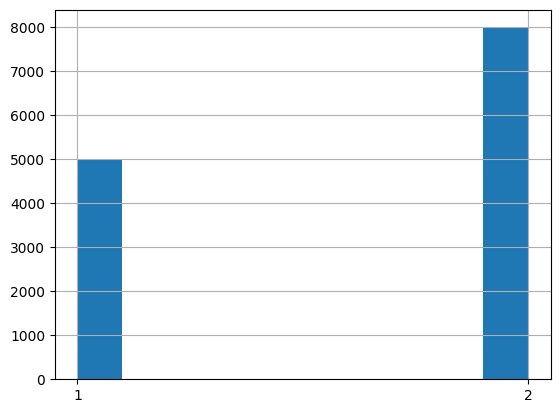

In [18]:
merged_df["Gender"].hist()

In [19]:
#merged_df  = merged_df[merged_df['Gender']=='1'] #for Male
#merged_df  = merged_df[merged_df['Gender']=='2'] #for Female
merged_df  = merged_df[merged_df['Outcome']==1] #for Success
#merged_df  = merged_df[merged_df['Outcome']=='2'] #for Failure


In [53]:
merged_df.shape

(1664, 73)

In [54]:
merged_df["User"].nunique()

170

In [20]:
merged_df[['TTCT_PRE_creativityIndex', 'Gender','TTCT_PRE_fluency','TTCT_PRE_elaboration','TTCT_PRE_flexibility','TTCT_PRE_originality']] =  merged_df[['TTCT_PRE_creativityIndex', 'Gender','TTCT_PRE_fluency','TTCT_PRE_elaboration','TTCT_PRE_flexibility','TTCT_PRE_originality']].astype('float')

In [21]:
target_values = merged_df[['TTCT_PRE_fluency','TTCT_PRE_elaboration','TTCT_PRE_flexibility','TTCT_PRE_originality']]

target_values_normalized = (target_values - target_values.min()) / (target_values.max() - target_values.min())

merged_df[['TTCT_PRE_fluency_norm','TTCT_PRE_elaboration_norm','TTCT_PRE_flexibility_norm','TTCT_PRE_originality_norm']] = target_values_normalized

In [22]:
target_values.describe()

,TTCT_PRE_fluency,TTCT_PRE_elaboration,TTCT_PRE_flexibility,TTCT_PRE_originality
count,1664.000000,1664.000000,1664.000000,1664.000000
mean,9.875000,2.683188,7.795673,0.942672
std,2.616153,0.829728,2.570536,0.024157
min,1.000000,1.000000,1.000000,0.833756
25%,9.000000,2.090909,6.000000,0.931484
50%,11.000000,2.545455,8.000000,0.944063
75%,12.000000,3.250000,10.000000,0.956412
max,16.000000,6.000000,14.000000,0.997973


### Choose one of the following methods: BERT, CodeBERt or GraphCodeBERT, create embeddings and then run the code

### BERT 

In [23]:
from transformers import BertTokenizer, BertModel
from transformers import RobertaTokenizer, RobertaModel
import torch

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

#tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
#model = RobertaModel.from_pretrained('roberta-base')

/home/dready/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [24]:
merged_df['Pseudocode_seq'] = merged_df.apply(lambda row: f"{row['Pseudocode']}", axis=1)
user_strings = merged_df.groupby('User')['Pseudocode_seq'].apply(' '.join).reset_index()

def get_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Get the embeddings of the [CLS] token
    
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# Generate embeddings for each user
user_strings['Embedding'] = user_strings['Pseudocode_seq'].apply(get_embedding)

# Convert the embeddings into a numpy array
embeddings = np.vstack(user_strings['Embedding'].values)

### CodeBERT

In [79]:
from transformers import RobertaTokenizer, RobertaModel
import torch
import numpy as np

# Load pre-trained CodeBERT model and tokenizer
tokenizer = RobertaTokenizer.from_pretrained('microsoft/codebert-base')
model = RobertaModel.from_pretrained('microsoft/codebert-base')

# Assuming `merged_df` contains the pseudocode sequences
merged_df['Pseudocode_seq'] = merged_df.apply(lambda row: f"{row['Pseudocode']}", axis=1)
user_strings = merged_df.groupby('User')['Pseudocode_seq'].apply(' '.join).reset_index()

# Function to generate embeddings using CodeBERT
def get_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Get the embeddings of the [CLS] token (CodeBERT uses Roberta architecture)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# Generate embeddings for each user
user_strings['Embedding'] = user_strings['Pseudocode_seq'].apply(get_embedding)

# Convert the embeddings into a numpy array
embeddings = np.vstack(user_strings['Embedding'].values)

/home/dready/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### GraphCodeBert

In [134]:
from transformers import RobertaTokenizer, RobertaModel
import torch
import numpy as np

# Load pre-trained GraphCodeBERT model and tokenizer
tokenizer = RobertaTokenizer.from_pretrained('microsoft/graphcodebert-base')
model = RobertaModel.from_pretrained('microsoft/graphcodebert-base')

# Assuming `merged_df` contains the pseudocode sequences
merged_df['Pseudocode_seq'] = merged_df.apply(lambda row: f"{row['Pseudocode']}", axis=1)
user_strings = merged_df.groupby('User')['Pseudocode_seq'].apply(' '.join).reset_index()

# Function to generate embeddings using GraphCodeBERT
def get_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Get the embeddings of the [CLS] token (GraphCodeBERT uses Roberta architecture)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# Generate embeddings for each user
user_strings['Embedding'] = user_strings['Pseudocode_seq'].apply(get_embedding)

# Convert the embeddings into a numpy array
embeddings = np.vstack(user_strings['Embedding'].values)

/home/dready/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#Code T5

In [ ]:
from transformers import RobertaTokenizer, T5ForConditionalGeneration
import torch
import numpy as np

# Load pre-trained CodeT5 model and tokenizer
tokenizer = RobertaTokenizer.from_pretrained('Salesforce/codet5-base')
model = T5ForConditionalGeneration.from_pretrained('Salesforce/codet5-base')

# Assuming `merged_df` contains the pseudocode sequences
merged_df['Pseudocode_seq'] = merged_df.apply(lambda row: f"{row['Pseudocode']}", axis=1)
user_strings = merged_df.groupby('User')['Pseudocode_seq'].apply(' '.join).reset_index()

# Function to generate embeddings using CodeT5
def get_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model.encoder(**inputs)
    # Get the embeddings of the last hidden state
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# Generate embeddings for each user
user_strings['Embedding'] = user_strings['Pseudocode_seq'].apply(get_embedding)

# Convert the embeddings into a numpy array
embeddings = np.vstack(user_strings['Embedding'].values)

In [135]:
user_strings

,User,Pseudocode_seq,Embedding
0,d2o730,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.24841285, 0.2199842, -0.15315959, 0.0650374..."
1,d2o740,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.28009745, 0.270459, -0.15534751, -0.1021087..."
2,d2o75q,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.29125568, 0.2579558, -0.1492061, -0.0499835..."
3,d2o764,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.21220437, 0.20093551, -0.16747649, 0.118732..."
4,d2o78q,TURN-RIGHT TURN-LEFT FORWARD FORWARD FORWARD ...,"[0.25001606, 0.24826059, -0.15538073, 0.116332..."
...,...,...,...
165,g9op4q,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.27656177, 0.2860003, -0.13996258, -0.003016..."
166,g9op5n,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.21411328, 0.24587573, -0.17333871, 0.008118..."
167,g9op6x,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.2437786, 0.27976087, -0.1822112, 0.09535748..."
168,g9op7q,FORWARD FORWARD FORWARD FORWARD TURN-RIGHT FO...,"[0.24009632, 0.2826361, -0.14035484, 0.1152887..."


In [27]:
merged_df[['User','TTCT_PRE_fluency','TTCT_PRE_elaboration','TTCT_PRE_flexibility','TTCT_PRE_originality']]

,User,TTCT_PRE_fluency,TTCT_PRE_elaboration,TTCT_PRE_flexibility,TTCT_PRE_originality
1,e7jnp8,3.0,1.000000,2.0,0.875655
7,e7jnp8,3.0,1.000000,2.0,0.875655
9,e7jnp8,3.0,1.000000,2.0,0.875655
13,e7jnp8,3.0,1.000000,2.0,0.875655
15,e7jnp8,3.0,1.000000,2.0,0.875655
...,...,...,...,...,...
12938,dzloyw,11.0,2.636364,11.0,0.957563
12942,dzloyw,11.0,2.636364,11.0,0.957563
12950,dzloyw,11.0,2.636364,11.0,0.957563
12970,dzloyw,11.0,2.636364,11.0,0.957563


In [80]:
code_creat_users = merged_df[['User','TTCT_PRE_fluency','TTCT_PRE_elaboration','TTCT_PRE_flexibility','TTCT_PRE_originality']].drop_duplicates(keep='first').merge(user_strings)

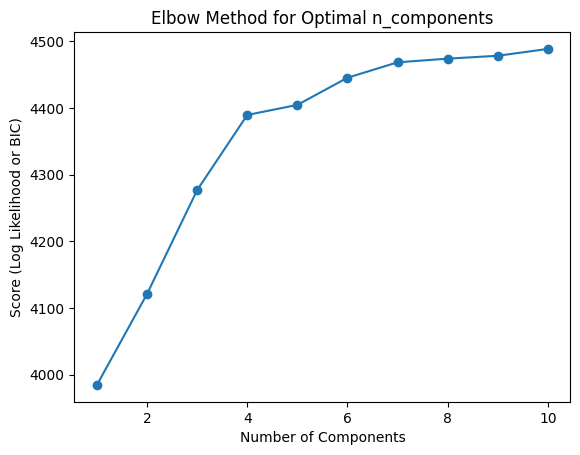

In [136]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

n_components_range = range(1, 11) 
scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(embeddings)
    scores.append(gmm.score(embeddings)) 

plt.plot(n_components_range, scores, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Score (Log Likelihood or BIC)')
plt.title('Elbow Method for Optimal n_components')
plt.show()

In [137]:
# Define the number of components
n_components = 7

# Initialize and fit the GMM
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(embeddings)

# Predict the cluster for each embedding
user_strings['gmm_cluster'] = gmm.predict(embeddings)


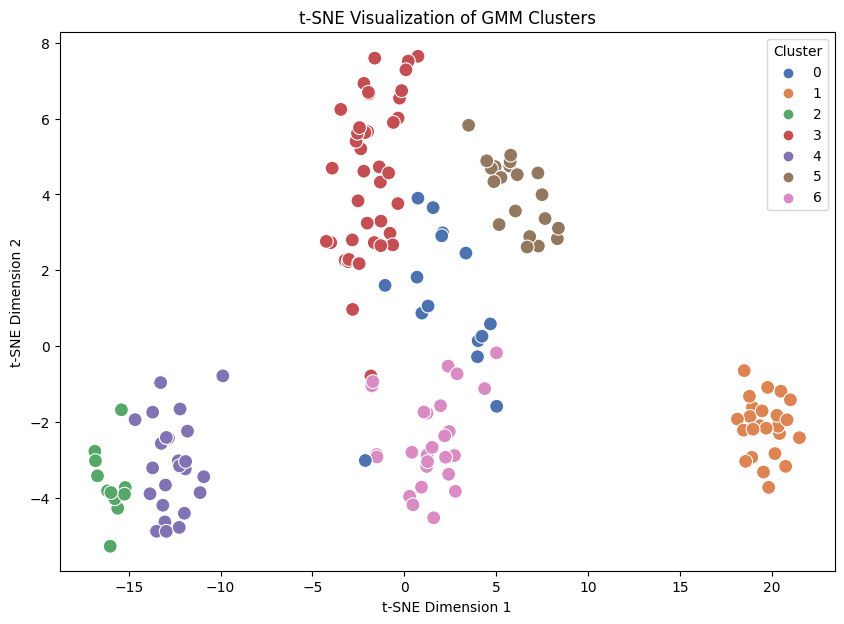

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(embeddings)

# 2. Create a DataFrame for easier plotting
import pandas as pd
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = user_strings['gmm_cluster'] # Add cluster labels

# 3. Plot the t-SNE visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE1', y='TSNE2', 
    hue='Cluster', 
    palette='deep', 
    data=tsne_df, 
    legend="full",
    s=100
)
plt.title('t-SNE Visualization of GMM Clusters')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.show()

In [139]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42) 
embeddings_reduced = pca.fit_transform(embeddings)

In [140]:
#GMM
n_components = 7

gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(embeddings_reduced)

# Predict the cluster for each embedding
user_strings['gmm_cluster'] = gmm.predict(embeddings_reduced)

In [141]:
log_likelihoods = gmm.score_samples(embeddings_reduced)

# Add log likelihoods to the DataFrame
user_strings['log_likelihood'] = log_likelihoods

# Calculate statistics for each cluster
cluster_stats = user_strings.groupby('gmm_cluster').agg(
    size=('gmm_cluster', 'size'),
    avg_log_likelihood=('log_likelihood', 'mean')
).reset_index()

print(cluster_stats)

   gmm_cluster  size  avg_log_likelihood
0            0    16           -1.568637
1            1    25           -0.717086
2            2    34           -1.119845
3            3    33            0.116210
4            4    18           -1.906194
5            5     6           -1.352123
6            6    38           -0.041210


### K-means

In [ ]:
#KMeans
from sklearn.cluster import KMeans

# Define the number of clusters (same as your current n_components)
n_clusters = 7

# Initialize and fit K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(embeddings_reduced)

# Predict the cluster for each embedding
user_strings['kmeans_cluster'] = kmeans.predict(embeddings_reduced)

In [ ]:
plt.figure(figsize=(10, 6))

# Plot data points colored by cluster
scatter = plt.scatter(embeddings_reduced[:, 0], embeddings_reduced[:, 1], 
                      c=user_strings['kmeans_cluster'], cmap='Set1')

# Plot cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            marker='x', s=200, linewidths=3, color='black', label='Centroids')

plt.title('K-means Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [ ]:
user_string = user_strings.copy()

In [ ]:
merged_df = pd.merge(merged_df, user_string[['User',"kmeans_cluster"]], on='User')

In [ ]:
merged_df.groupby("kmeans_cluster")[['TTCT_PRE_creativityIndex','TTCT_PRE_fluency', 'TTCT_PRE_elaboration', 'TTCT_PRE_flexibility', 'TTCT_PRE_originality','Gender']].mean()

### After choosing KMeans or GMM

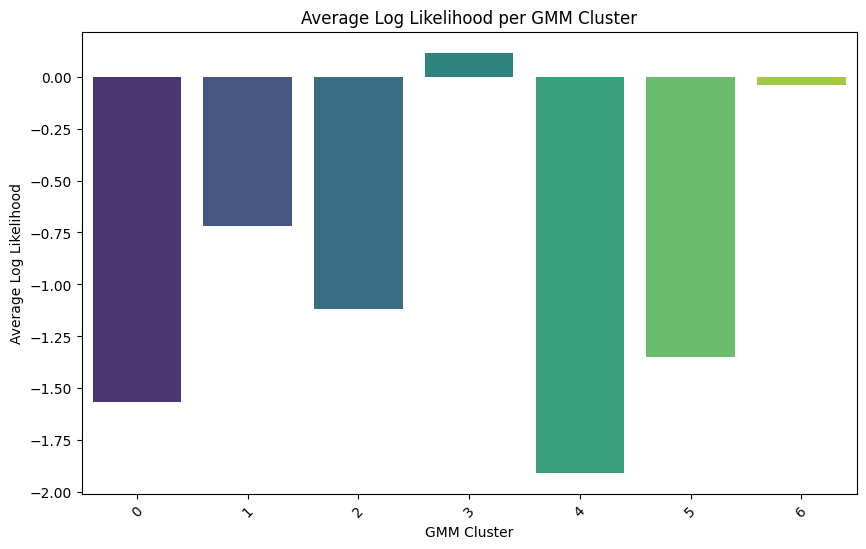

In [142]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(data=cluster_stats, x='gmm_cluster', y='avg_log_likelihood', palette='viridis')

# Add labels and title
plt.xlabel('GMM Cluster')
plt.ylabel('Average Log Likelihood')
plt.title('Average Log Likelihood per GMM Cluster')
plt.xticks(rotation=45)
plt.show()

In [95]:
size_threshold = cluster_stats['avg_log_likelihood'].min()

outlier_clusters_by_size = cluster_stats[cluster_stats['size'] > size_threshold]
print("Outlier clusters based on size:\n", outlier_clusters_by_size)

Outlier clusters based on size:
    gmm_cluster  size  avg_log_likelihood
0            0    18           -2.615730
1            1    22           -2.446025
2            2    14           -3.521489
3            3    36           -1.375511
4            4    39           -1.650995
5            5     8           -2.756747
6            6    33           -1.864018


In [96]:

log_likelihood_threshold = cluster_stats['avg_log_likelihood'].quantile(0.95)

outlier_clusters_by_log_likelihood = cluster_stats[cluster_stats['avg_log_likelihood'] > log_likelihood_threshold]
print("Outlier clusters based on log likelihood:\n", outlier_clusters_by_log_likelihood)


Outlier clusters based on log likelihood:
    gmm_cluster  size  avg_log_likelihood
3            3    36           -1.375511


In [98]:

outlier_clusters = cluster_stats[
    (cluster_stats['size'] < size_threshold) & 
    (cluster_stats['avg_log_likelihood'] > log_likelihood_threshold)
]


In [99]:
# Print the DataFrame with cluster labels
print(user_strings)

       User                                     Pseudocode_seq  \
0    d2o730  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
1    d2o740  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
2    d2o75q  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
3    d2o764  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
4    d2o78q  TURN-RIGHT TURN-LEFT FORWARD FORWARD FORWARD  ...   
..      ...                                                ...   
165  g9op4q  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
166  g9op5n  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
167  g9op6x  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
168  g9op7q  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   
169  g9op9n  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...   

                                             Embedding  gmm_cluster  \
0    [0.15224381, 0.24727575, -0.36418974, 0.326877...            3   
1    [0.20258538, 0.16674721, -0.48504314, 0.335798...           

In [100]:
cluster_counts = user_strings['gmm_cluster'].value_counts().sort_index()

print(cluster_counts)

0    18
1    22
2    14
3    36
4    39
5     8
6    33
Name: gmm_cluster, dtype: int64


In [143]:
user_string = user_strings.copy()

In [155]:
# 0 for BERT
# 2 for CodeBERT
# 4 for GraphCodeBERT
user_string['is_atypical'] = (user_strings['gmm_cluster'] == 4)# | (user_strings['gmm_cluster'] == 2) #| (user_strings['gmm_cluster'] ==3)

In [156]:
# Merge the user_strings with the original data to calculate averages
merged_df = pd.merge(merged_df, user_string[['User', 'is_atypical']], on='User')

In [157]:
outlier_sequences = user_string[user_string['is_atypical']]
print(outlier_sequences[['User', 'Pseudocode_seq']])

       User                                     Pseudocode_seq
1    d2o740  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
2    d2o75q  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
29   d80oly  FORWARD FORWARD FORWARD  FORWARD FORWARD TURN-...
39   dn31xn  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
40   dqx40n  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
41   dqx42w  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
48   dqx4r5  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
49   dqx4vj  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
54   dw1l76  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
77   e1n65v  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
79   e4qkxj  FORWARD FORWARD FORWARD FORWARD  FORWARD FORWA...
93   ejvx08  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
100  em2047  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
102  em207p  FORWARD FORWARD  FORWARD FORWARD TURN-RIGHT FO...
105  em20np  FORWARD FORWARD  FORWARD FORWARD TURN-RIGH

In [158]:
atypical_user_ids = outlier_sequences["User"]

In [159]:
atypical_user_ids

1      d2o740
2      d2o75q
29     d80oly
39     dn31xn
40     dqx40n
41     dqx42w
48     dqx4r5
49     dqx4vj
54     dw1l76
77     e1n65v
79     e4qkxj
93     ejvx08
100    em2047
102    em207p
105    em20np
106    em20o8
125    eyqn01
165    g9op4q
Name: User, dtype: object

In [107]:
merged_df_atypical = merged_df[merged_df["User"].isin(atypical_user_ids)]

In [108]:
merged_df_typical = merged_df[~merged_df["User"].isin(atypical_user_ids)]

In [109]:
merged_df_atypical.to_csv('atypical_users.csv', index=False)

In [110]:
merged_df_typical.to_csv('typical_users.csv', index=False)

In [111]:
merged_df_typical.columns

Index(['BrowserTimestamp', 'DbLongTimestamp', 'DbTimestamp', 'Id',
       'JSPseudocode', 'KodetuVersion', 'Level', 'Outcome', 'Pseudocode',
       'SessionId', 'XMLPseudocode()', 'KodetuSesion', 'Dataset', 'Error',
       'Path length', 'Steps length', 'Trace', 'loop', 'fall', 'target',
       'min.distancetoPath', 'distToGoal', 'User', 'Age', 'Gender', 'Class',
       'CodeKnow', 'TechAff', 'TechAff_median', 'Pre_Post', 'Pre_Post_INT',
       'TTCTPre', 'TTCTPost', 'KODETU_Pre', 'KODETU_Post', 'INT_sessions',
       'INT_sessions_not_zero', 'INT_sessions_true_false', 'INT_count_items',
       'TTCT_PRE_fluency', 'TTCT_PRE_fluency_log', 'TTCT_PRE_originality',
       'TTCT_PRE_originality_log', 'TTCT_PRE_flexibility',
       'TTCT_PRE_elaboration', 'TTCT_PRE_creativityIndex', 'TTCT_POST_fluency',
       'TTCT_POST_fluency_log', 'TTCT_POST_originality',
       'TTCT_POST_originality_log', 'TTCT_POST_flexibility',
       'TTCT_POST_elaboration', 'TTCT_POST_creativityIndex', 'KODETU_PRE_

In [152]:
from collections import Counter
import re

def clean_text(text):
    return re.sub(r'[(),]', '', text)

outlier_sequences = user_string[user_string['is_atypical']]['Pseudocode_seq'].apply(clean_text)
non_outlier_sequences = user_string[user_string['is_atypical'] == False]['Pseudocode_seq'].apply(clean_text)

outlier_words = set(word for text in outlier_sequences for word in text.split())
non_outlier_words = set(word for text in non_outlier_sequences for word in text.split())

num_unique_outlier_words = len(outlier_words)
num_unique_non_outlier_words = len(non_outlier_words)

print("num_unique_outlier_words is ", num_unique_outlier_words)
print("num_unique_non_outlier_words is ", num_unique_non_outlier_words)

num_unique_outlier_words is  8
num_unique_non_outlier_words is  8


In [153]:
non_outlier_words - outlier_words 

set()

In [116]:
#outlier_sequences[['User', 'Pseudocode_seq']].to_csv('outlier_sequences.csv', index=False)

In [118]:
#non_outlier_sequences = user_string[user_string['is_atypical']==False]
#outlier_sequences[['User', 'Pseudocode_seq']].to_csv('non_outlier_sequences.csv', index=False)

In [160]:
merged_df['is_atypical']

0       False
1       False
2       False
3       False
4       False
        ...  
1659    False
1660    False
1661    False
1662    False
1663    False
Name: is_atypical, Length: 1664, dtype: bool

In [161]:
# Calculate average values of specified columns for inliers and outliers
columns_of_interest = ['TTCT_PRE_creativityIndex','TTCT_PRE_fluency', 'TTCT_PRE_elaboration', 'TTCT_PRE_flexibility', 'TTCT_PRE_originality','Gender']
avg_inliers = merged_df[merged_df['is_atypical']!=True][columns_of_interest].mean()
avg_outliers = merged_df[merged_df['is_atypical']==True][columns_of_interest].mean()

print("\nAverage values for specified columns (inliers):")
print(avg_inliers)
print("\nAverage values for specified columns (outliers):")
print(avg_outliers)

std_inliers = merged_df[merged_df['is_atypical']!=True][columns_of_interest].std()
std_outliers = merged_df[merged_df['is_atypical']==True][columns_of_interest].std()

print("\nStd values for specified columns (inliers):")
print(std_inliers)
print("\nStd values for specified columns (outliers):")
print(std_outliers)

median_inliers = merged_df[merged_df['is_atypical']!=True][columns_of_interest].median()
median_outliers = merged_df[merged_df['is_atypical']==True][columns_of_interest].median()

print("\nMedian values for specified columns (inliers):")
print(median_inliers)
print("\nMedian values for specified columns (outliers):")
print(median_outliers)



Average values for specified columns (inliers):
TTCT_PRE_creativityIndex    5.348172
TTCT_PRE_fluency            9.883068
TTCT_PRE_elaboration        2.732019
TTCT_PRE_flexibility        7.835232
TTCT_PRE_originality        0.942371
Gender                      1.618071
dtype: float64

Average values for specified columns (outliers):
TTCT_PRE_creativityIndex    5.232897
TTCT_PRE_fluency            9.844380
TTCT_PRE_elaboration        2.497855
TTCT_PRE_flexibility        7.645533
TTCT_PRE_originality        0.943817
Gender                      1.276657
dtype: float64

Std values for specified columns (inliers):
TTCT_PRE_creativityIndex    1.194716
TTCT_PRE_fluency            2.581792
TTCT_PRE_elaboration        0.840775
TTCT_PRE_flexibility        2.564553
TTCT_PRE_originality        0.022327
Gender                      0.486044
dtype: float64

Std values for specified columns (outliers):
TTCT_PRE_creativityIndex    1.241421
TTCT_PRE_fluency            2.746304
TTCT_PRE_elaboration     

In [162]:
merged_df[merged_df['is_atypical'] == True][columns_of_interest].mean()

TTCT_PRE_creativityIndex    5.232897
TTCT_PRE_fluency            9.844380
TTCT_PRE_elaboration        2.497855
TTCT_PRE_flexibility        7.645533
TTCT_PRE_originality        0.943817
Gender                      1.276657
dtype: float64

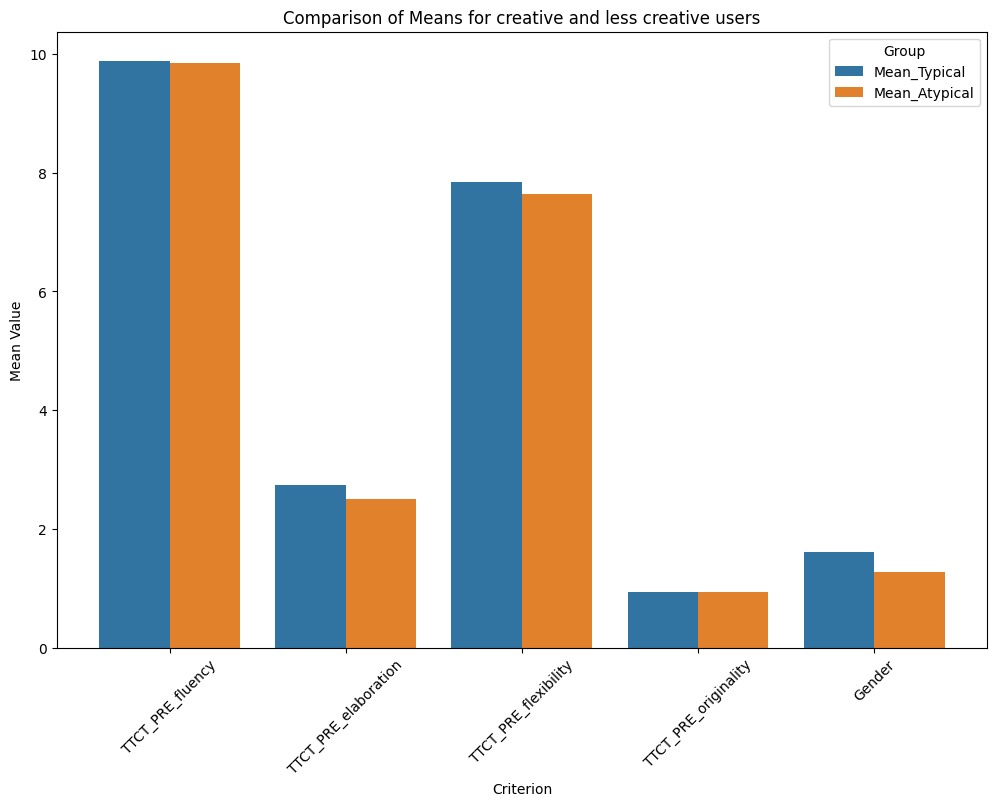

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns of interest
columns_of_interest = ['TTCT_PRE_fluency', 'TTCT_PRE_elaboration', 'TTCT_PRE_flexibility', 'TTCT_PRE_originality', 'Gender'] #$'TTCT_PRE_creativityIndex',

# Calculate means and standard deviations
avg_inliers = merged_df[merged_df['is_atypical'] == False][columns_of_interest].mean()
#std_inliers = merged_df[merged_df['is_atypical'] == False][columns_of_interest].std()

avg_atypical = merged_df[merged_df['is_atypical'] == True][columns_of_interest].mean()
#std_atypical = merged_df[merged_df['is_atypical'] == True][columns_of_interest].std()

data = {
    'Criterion': columns_of_interest,
    'Mean_Typical': avg_inliers.values,
#    'Std_Typical': std_inliers.values,
    'Mean_Atypical': avg_atypical.values,
#    'Std_Atypical': std_atypical.values
}
df_viz = pd.DataFrame(data)

df_viz_melted = df_viz.melt(id_vars='Criterion', value_vars=['Mean_Typical', 'Mean_Atypical'], var_name='Group', value_name='Mean')
#df_viz_melted['Std'] = df_viz_melted.apply(lambda row: std_inliers[row['Criterion']] if row['Group'] == 'Mean_Typical' else std_atypical[row['Criterion']], axis=1)

plt.figure(figsize=(12, 8))
sns.barplot(x='Criterion', y='Mean', hue='Group', data=df_viz_melted, errorbar=None)

# Add error bars
for i in range(len(df_viz_melted)):
    plt.errorbar(x=i//2, y=df_viz_melted.iloc[i]['Mean'], fmt='none', c='black', capsize=5) #yerr=df_viz_melted.iloc[i]['Std'], 

plt.title('Comparison of Means for creative and less creative users')
plt.xlabel('Criterion')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(title='Group')
plt.show()

/tmp/ipykernel_580568/3072137055.py:29: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ellipse = Ellipse(mean[:2], v[0], v[1], angle, edgecolor=colors(i), lw=1.5, facecolor='none')


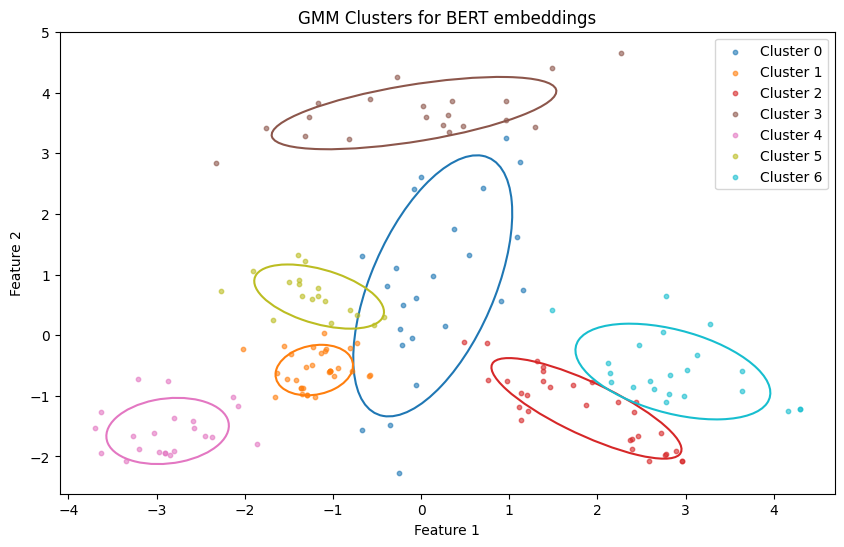

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
import matplotlib.cm as cm

n_components = 7
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(embeddings_reduced)

# Predict the cluster for each data point
labels = gmm.predict(embeddings_reduced)

# Define a colormap with a different color for each cluster
colors = cm.get_cmap('tab10', n_components)

# Plot data points with colors for each cluster
plt.figure(figsize=(10, 6))
for i in range(n_components):
    cluster_data = embeddings_reduced[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], s=10, color=colors(i), label=f'Cluster {i}', alpha=0.6)

    # Plot ellipse for each component
    mean = gmm.means_[i]
    cov = gmm.covariances_[i][:2, :2] if gmm.covariance_type == 'full' else np.diag(gmm.covariances_[i])
    v, w = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(w[0][1], w[0][0]))
    v = 2. * np.sqrt(2.) * np.sqrt(v)  # Scale for better visualization
    ellipse = Ellipse(mean[:2], v[0], v[1], angle, edgecolor=colors(i), lw=1.5, facecolor='none')
    plt.gca().add_patch(ellipse)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Clusters for BERT embeddings")
plt.legend()
plt.show()

### CodeBERT

/tmp/ipykernel_580568/1119827204.py:29: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ellipse = Ellipse(mean[:2], v[0], v[1], angle, edgecolor=colors(i), lw=1.5, facecolor='none')


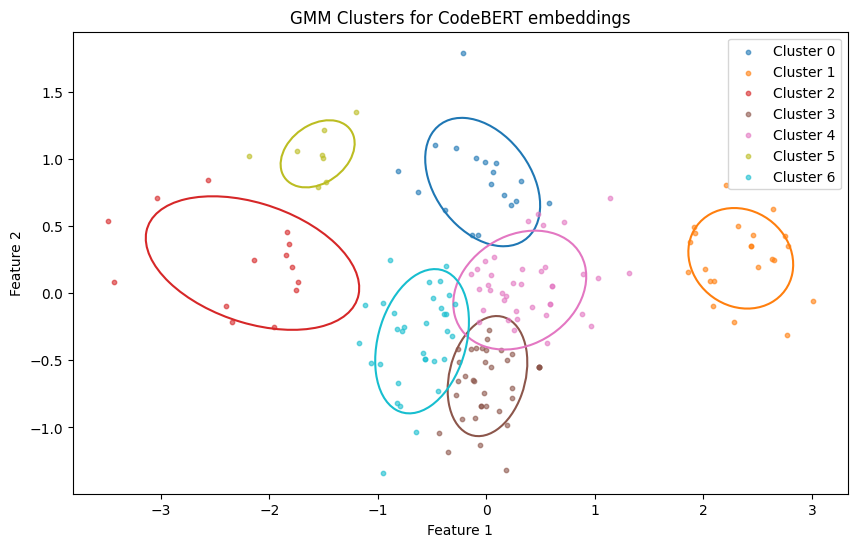

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
import matplotlib.cm as cm

n_components = 7
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(embeddings_reduced)

# Predict the cluster for each data point
labels = gmm.predict(embeddings_reduced)

# Define a colormap with a different color for each cluster
colors = cm.get_cmap('tab10', n_components)

# Plot data points with colors for each cluster
plt.figure(figsize=(10, 6))
for i in range(n_components):
    cluster_data = embeddings_reduced[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], s=10, color=colors(i), label=f'Cluster {i}', alpha=0.6)

    # Plot ellipse for each component
    mean = gmm.means_[i]
    cov = gmm.covariances_[i][:2, :2] if gmm.covariance_type == 'full' else np.diag(gmm.covariances_[i])
    v, w = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(w[0][1], w[0][0]))
    v = 2. * np.sqrt(2.) * np.sqrt(v)  # Scale for better visualization
    ellipse = Ellipse(mean[:2], v[0], v[1], angle, edgecolor=colors(i), lw=1.5, facecolor='none')
    plt.gca().add_patch(ellipse)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Clusters for CodeBERT embeddings")
plt.legend()
plt.show()

/tmp/ipykernel_580568/3471832294.py:29: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ellipse = Ellipse(mean[:2], v[0], v[1], angle, edgecolor=colors(i), lw=1.5, facecolor='none')


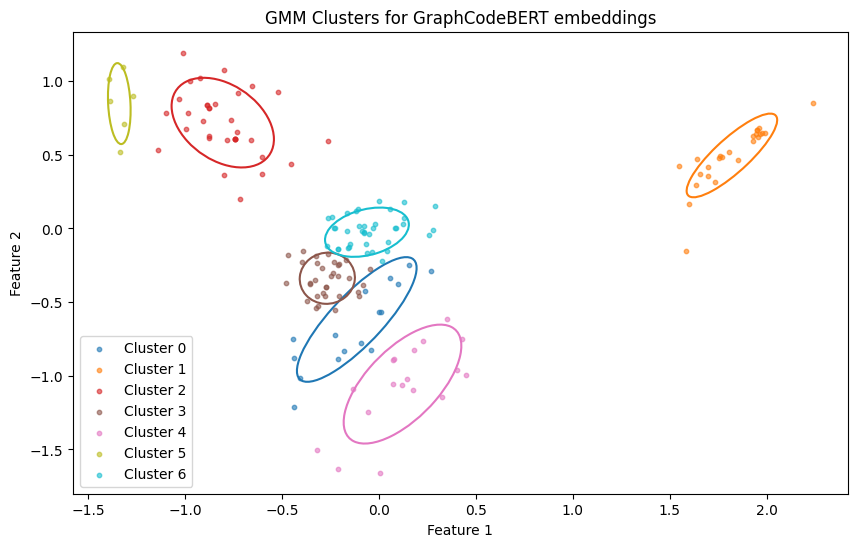

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
import matplotlib.cm as cm

n_components = 7
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(embeddings_reduced)

# Predict the cluster for each data point
labels = gmm.predict(embeddings_reduced)

# Define a colormap with a different color for each cluster
colors = cm.get_cmap('tab10', n_components)

# Plot data points with colors for each cluster
plt.figure(figsize=(10, 6))
for i in range(n_components):
    cluster_data = embeddings_reduced[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], s=10, color=colors(i), label=f'Cluster {i}', alpha=0.6)

    # Plot ellipse for each component
    mean = gmm.means_[i]
    cov = gmm.covariances_[i][:2, :2] if gmm.covariance_type == 'full' else np.diag(gmm.covariances_[i])
    v, w = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(w[0][1], w[0][0]))
    v = 2. * np.sqrt(2.) * np.sqrt(v)  # Scale for better visualization
    ellipse = Ellipse(mean[:2], v[0], v[1], angle, edgecolor=colors(i), lw=1.5, facecolor='none')
    plt.gca().add_patch(ellipse)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Clusters for GraphCodeBERT embeddings")
plt.legend()
plt.show()

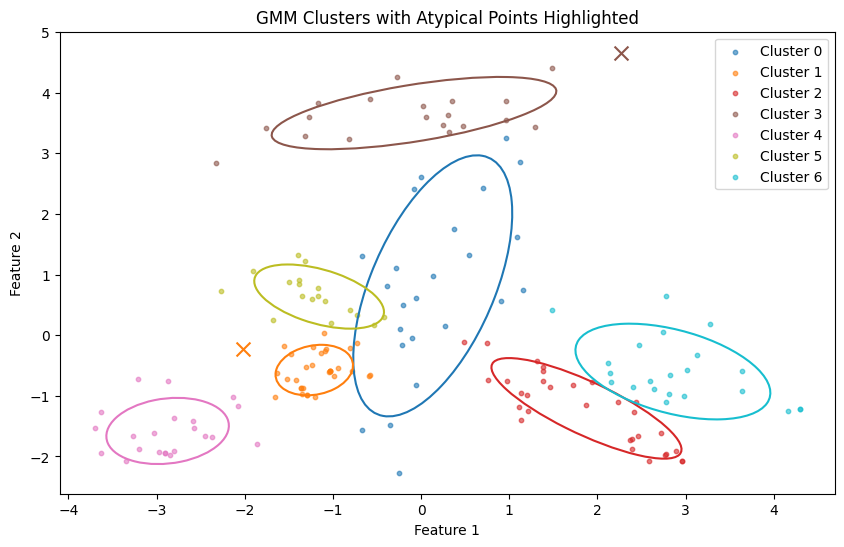

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
import matplotlib.cm as cm
from scipy.stats import chi2

n_components = 7
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(embeddings_reduced)

# Predict the cluster for each data point
labels = gmm.predict(embeddings_reduced)

# Calculate Mahalanobis distance for each point to its cluster center
is_atypical = np.zeros(len(embeddings_reduced), dtype=bool)
for i in range(len(embeddings_reduced)):
    cluster_id = labels[i]
    point = embeddings_reduced[i]
    mean = gmm.means_[cluster_id]
    cov = gmm.covariances_[cluster_id]
    
    # Calculate Mahalanobis distance
    diff = point - mean
    mah_dist = diff.dot(np.linalg.inv(cov)).dot(diff)
    
    # Chi-square threshold for 2 degrees of freedom (2D data) at 95% confidence
    threshold = chi2.ppf(0.95, df=2)
    is_atypical[i] = mah_dist > threshold

# Plot with atypical points highlighted
plt.figure(figsize=(10, 6))

# Plot normal points
for i in range(n_components):
    cluster_data = embeddings_reduced[(labels == i) & ~is_atypical]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
               s=10, color=colors(i), label=f'Cluster {i}', alpha=0.6)

# Plot atypical points with 'x' markers
atypical_points = embeddings_reduced[is_atypical]
atypical_labels = labels[is_atypical]
for i in range(n_components):
    cluster_atypical = atypical_points[atypical_labels == i]
    plt.scatter(cluster_atypical[:, 0], cluster_atypical[:, 1], 
               marker='x', s=100, color=colors(i))#, label=f'Atypical {i}')

# Plot ellipses
for i in range(n_components):
    mean = gmm.means_[i]
    cov = gmm.covariances_[i][:2, :2]
    v, w = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(w[0][1], w[0][0]))
    v = 2. * np.sqrt(2.) * np.sqrt(v)
    ellipse = Ellipse(xy=mean[:2], width=v[0], height=v[1], angle=angle, 
                  edgecolor=colors(i), lw=1.5, facecolor='none')
    plt.gca().add_patch(ellipse)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Clusters with Atypical Points Highlighted")
plt.legend()
plt.show()

# Add is_atypical to your dataframe
user_strings['is_atypical'] = is_atypical

In [68]:
from scipy import stats

typical_values = merged_df[merged_df['is_atypical'] == False]['TTCT_PRE_creativityIndex']
atypical_values = merged_df[merged_df['is_atypical'] == True]['TTCT_PRE_creativityIndex']

t_stat, p_value = stats.ttest_ind(typical_values, atypical_values)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -3.6158682601304366, P-value: 0.00030827566890917057


In [69]:
typical_values = merged_df[merged_df['is_atypical'] == False]['TTCT_PRE_fluency']
atypical_values = merged_df[merged_df['is_atypical'] == True]['TTCT_PRE_fluency']

t_stat, p_value = stats.ttest_ind(typical_values, atypical_values)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -3.5925947797323623, P-value: 0.00033693594672767077


In [70]:
typical_values = merged_df[merged_df['is_atypical'] == False]['TTCT_PRE_elaboration']
atypical_values = merged_df[merged_df['is_atypical'] == True]['TTCT_PRE_elaboration']

t_stat, p_value = stats.ttest_ind(typical_values, atypical_values)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -0.8218306089772236, P-value: 0.41129118836044276


In [71]:
typical_values = merged_df[merged_df['is_atypical'] == False]['TTCT_PRE_flexibility']
atypical_values = merged_df[merged_df['is_atypical'] == True]['TTCT_PRE_flexibility']

t_stat, p_value = stats.ttest_ind(typical_values, atypical_values)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -2.883662230333803, P-value: 0.003981395971183374


In [72]:
typical_values = merged_df[merged_df['is_atypical'] == False]['TTCT_PRE_originality']
atypical_values = merged_df[merged_df['is_atypical'] == True]['TTCT_PRE_originality']

t_stat, p_value = stats.ttest_ind(typical_values, atypical_values)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 3.1567520753811125, P-value: 0.0016239986048442589
